# Handwritten OCR Hyperparameter Search Notebook (Janus-Pro-1B)

This notebook is a streamlined version for **3 fine-tuning experiments** to find the best model.

## What is included
- Shared dataset prep
- Shared train/val split
- 3 experiment runs with different hyperparameters
- Per-run adapter save + metrics summary
- Comparison plots to select the best run

## What is intentionally removed
- No crop-creation cell (uses existing crops if available)
- No extra debug-only cells

> Paths remain unchanged for Google Colab usage.

In [ ]:
# Colab setup (run once)
%pip -q install -U transformers==4.46.3 datasets accelerate peft bitsandbytes sentencepiece Pillow==9.5.0 opencv-python-headless evaluate jiwer

In [ ]:
import os
import re
import gc
import json
import random
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
from datasets import Dataset as HFDataset

from transformers import (
    AutoConfig,
    AutoProcessor,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
)

from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

CUDA available: True
GPU: Tesla T4
VRAM (GB): 15.64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -------- Config --------
@dataclass
class CFG:
    model_name: str = 'deepseek-ai/Janus-Pro-1B'
    csv_path: str = '/content/transcriptions.csv'
    image_root: str = '/content/drive/MyDrive/data'
    work_dir: str = '/content/drive/MyDrive/brainink_janus_hw'

    min_target_chars: int = 20
    max_target_chars: int = 1200
    max_samples: int | None = None
    val_ratio: float = 0.1

    max_length: int = 1024

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)

PROMPT = 'Read the handwritten text in this image and transcribe it exactly.'

# 3 experiments total (edit values if needed)
EXPERIMENTS = [
    {
        'name': 'exp_1_baseline',
        'num_train_epochs': 2,
        'learning_rate': 2e-4,
        'gradient_accumulation_steps': 8,
        'lora_r': 16,
        'lora_alpha': 32,
        'lora_dropout': 0.05,
        'per_device_train_batch_size': 1,
        'per_device_eval_batch_size': 1,
        'weight_decay': 0.01,
        'warmup_ratio': 0.03,
    },
    {
        'name': 'exp_2_lower_lr_more_epochs',
        'num_train_epochs': 3,
        'learning_rate': 1e-4,
        'gradient_accumulation_steps': 8,
        'lora_r': 16,
        'lora_alpha': 32,
        'lora_dropout': 0.05,
        'per_device_train_batch_size': 1,
        'per_device_eval_batch_size': 1,
        'weight_decay': 0.01,
        'warmup_ratio': 0.05,
    },
    {
        'name': 'exp_3_higher_capacity_lora',
        'num_train_epochs': 2,
        'learning_rate': 2e-4,
        'gradient_accumulation_steps': 8,
        'lora_r': 32,
        'lora_alpha': 64,
        'lora_dropout': 0.10,
        'per_device_train_batch_size': 1,
        'per_device_eval_batch_size': 1,
        'weight_decay': 0.01,
        'warmup_ratio': 0.03,
    },
]

print('Model:', cfg.model_name)
print('CSV:', cfg.csv_path)
print('Image root:', cfg.image_root)
print('Work dir:', cfg.work_dir)
print('Experiments:', [e['name'] for e in EXPERIMENTS])

Model: deepseek-ai/Janus-Pro-1B
CSV: /content/transcriptions.csv
Image root: /content/drive/MyDrive/data
Work dir: /content/drive/MyDrive/brainink_janus_hw
Experiments: ['exp_1_baseline', 'exp_2_lower_lr_more_epochs', 'exp_3_higher_capacity_lora']


In [ ]:
# -------- Parse transcription + build reusable dataset (no crop creation) --------
def normalize_space(text: str) -> str:
    text = text.replace('\r', '\n')
    text = re.sub(r'\n+', '\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()


def extract_printed_target(raw: str) -> str:
    if not isinstance(raw, str):
        return ''

    text = normalize_space(raw)
    lines = [ln.strip() for ln in text.split('\n') if ln.strip()]
    if not lines:
        return ''

    if lines and lines[0].lower().startswith('sentence database'):
        lines = lines[1:]
    if lines and re.match(r'^[A-Za-z]\d{2}-\d{3}', lines[0]):
        lines = lines[1:]

    cut = []
    for ln in lines:
        if ln.lower().startswith('name'):
            break
        cut.append(ln)
    lines = cut
    if not lines:
        return ''

    printed = []
    short_streak = 0
    for ln in lines:
        printed.append(ln)
        if len(ln) < 35:
            short_streak += 1
        else:
            short_streak = 0

        if len(printed) >= 3 and short_streak >= 2:
            printed = printed[:-2]
            break

    if not printed:
        printed = lines[:6]

    label = ' '.join(printed)
    label = re.sub(r'\s+', ' ', label).strip()
    return label


def resolve_input_path(rel_image_path: str) -> str:
    crop_candidate = Path(cfg.work_dir) / 'crops' / rel_image_path
    if crop_candidate.exists():
        return str(crop_candidate)
    return str((Path(cfg.image_root) / rel_image_path).resolve())


df = pd.read_csv(cfg.csv_path)
df['image_path'] = df['image_path'].astype(str).str.strip()
df['target_text'] = df['transcription'].apply(extract_printed_target)

df = df[df['target_text'].str.len() >= cfg.min_target_chars].copy()
df = df[df['target_text'].str.len() <= cfg.max_target_chars].copy()

df['input_path'] = df['image_path'].apply(resolve_input_path)
df = df[df['input_path'].apply(lambda p: Path(p).exists())].copy()

if cfg.max_samples is not None:
    df = df.sample(n=min(cfg.max_samples, len(df)), random_state=SEED).reset_index(drop=True)

df = df.reset_index(drop=True)
print('Usable rows:', len(df))
print('Rows using existing crops:', int(df['image_path'].apply(lambda p: (Path(cfg.work_dir) / 'crops' / p).exists()).sum()))
display(df[['image_path', 'input_path', 'target_text']].head(5))

idx = np.arange(len(df))
rng = np.random.default_rng(SEED)
rng.shuffle(idx)
val_size = max(1, int(len(df) * cfg.val_ratio))
val_idx = idx[:val_size]
train_idx = idx[val_size:]

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

train_hf = HFDataset.from_pandas(train_df[['input_path', 'target_text']], preserve_index=False)
val_hf = HFDataset.from_pandas(val_df[['input_path', 'target_text']], preserve_index=False)

print('Train size:', len(train_df))
print('Val size:', len(val_df))

Usable rows: 1520
Rows using existing crops: 1520


,image_path,input_path,target_text
0,000/a01-000u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,A MOVE to stop Mr. Gaitskell from nominating a...
1,000/a01-003u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,"Though they may gather some Left-wing support,..."
2,000/a01-007u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,"Since 1958, 13 Labour life Peers and Peeresses..."
3,000/a01-011u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,Delegates from Mr. Kenneth Kaunda's United Nat...
4,000/a01-014u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,Sir Roy's United Federal Party is boycotting t...


Train size: 1368
Val size: 152


## Multi-run training functions
This cell defines reusable functions to train one experiment at a time and collect comparable metrics.

In [ ]:
# -------- Reusable model/training helpers --------
import subprocess
import sys

try:
    import janus  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'git+https://github.com/deepseek-ai/Janus.git'])
    import janus  # noqa: F401

from janus.models import VLChatProcessor


def load_base_components(model_name: str):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    )

    cfg_obj = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
    print('HF config model_type:', getattr(cfg_obj, 'model_type', 'unknown'))

    try:
        processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)
    except Exception:
        processor = VLChatProcessor.from_pretrained(model_name)

    base_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config if torch.cuda.is_available() else None,
        device_map='auto',
        trust_remote_code=True,
    )
    return processor, base_model


def add_lora_to_language_model(base_model, lora_r: int, lora_alpha: int, lora_dropout: float):
    lm_for_lora = base_model.language_model

    if not isinstance(lm_for_lora, PeftModel):
        if getattr(lm_for_lora, 'supports_gradient_checkpointing', False):
            lm_for_lora.gradient_checkpointing_enable()

        try:
            lm_for_lora = prepare_model_for_kbit_training(lm_for_lora, use_gradient_checkpointing=False)
        except NotImplementedError:
            pass

        preferred_targets = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
        available_targets = sorted({
            name.split('.')[-1]
            for name, module in lm_for_lora.named_modules()
            if hasattr(module, 'weight') and name.split('.')[-1] in preferred_targets
        })
        if not available_targets:
            raise RuntimeError('No LoRA target modules found in language_model.')

        lora_cfg = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            bias='none',
            task_type='CAUSAL_LM',
            target_modules=available_targets,
        )
        peft_lm = get_peft_model(lm_for_lora, lora_cfg)
        peft_lm.print_trainable_parameters()
        base_model.language_model = peft_lm

    return base_model


class JanusTrainerWrapper(torch.nn.Module):
    def __init__(self, mm_model):
        super().__init__()
        self.mm_model = mm_model

    @property
    def language_model(self):
        return self.mm_model.language_model

    @property
    def config(self):
        return self.mm_model.config

    @property
    def device(self):
        return next(self.mm_model.parameters()).device

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        pixel_values=None,
        images_seq_mask=None,
        images_emb_mask=None,
        labels=None,
        **kwargs,
    ):
        if pixel_values is not None and images_seq_mask is not None and images_emb_mask is not None:
            if input_ids is not None:
                input_ids = input_ids.to(self.device)
            if attention_mask is not None:
                attention_mask = attention_mask.to(self.device)
            if labels is not None:
                labels = labels.to(self.device)

            try:
                vision_dtype = next(self.mm_model.vision_model.parameters()).dtype
                pixel_values = pixel_values.to(device=self.device, dtype=vision_dtype)
            except Exception:
                pixel_values = pixel_values.to(self.device)

            prepared = {
                'input_ids': input_ids,
                'attention_mask': attention_mask,
                'pixel_values': pixel_values,
                'images_seq_mask': images_seq_mask.to(self.device),
                'images_emb_mask': images_emb_mask.to(self.device),
            }

            with torch.no_grad():
                inputs_embeds = self.mm_model.prepare_inputs_embeds(**prepared)

            return self.language_model(
                inputs_embeds=inputs_embeds,
                attention_mask=attention_mask,
                labels=labels,
                return_dict=True,
            )

        return self.language_model(
            input_ids=input_ids.to(self.device) if input_ids is not None else None,
            attention_mask=attention_mask.to(self.device) if attention_mask is not None else None,
            labels=labels.to(self.device) if labels is not None else None,
            return_dict=True,
        )


def format_training_text(processor, answer_text: str):
    tokenizer_obj = getattr(processor, 'tokenizer', None)
    has_template = bool(getattr(tokenizer_obj, 'chat_template', None))

    if hasattr(processor, 'apply_chat_template') and has_template:
        msgs = [
            {
                'role': 'user',
                'content': [
                    {'type': 'image'},
                    {'type': 'text', 'text': PROMPT},
                ],
            },
            {
                'role': 'assistant',
                'content': [
                    {'type': 'text', 'text': answer_text},
                ],
            },
        ]
        try:
            return processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
        except Exception:
            pass

    return f'<image>\n{PROMPT}\nAssistant: {answer_text}'


def processor_supports_images_arg(proc):
    try:
        _ = proc(images=[Image.new('RGB', (16, 16))], text=['test'], return_tensors='pt')
        return True
    except TypeError as err:
        return not ('unexpected keyword argument' in str(err) and 'images' in str(err))
    except Exception:
        return True


def build_collate_fn(processor, model_name: str, max_length: int):
    supports_images = processor_supports_images_arg(processor)
    vl_processor = None if supports_images else VLChatProcessor.from_pretrained(model_name)
    print('Processor supports images arg:', supports_images)

    def collate_fn(batch):
        sample = batch[0]
        image = Image.open(sample['input_path']).convert('RGB')
        answer_text = sample['target_text']

        if supports_images:
            texts = [format_training_text(processor, answer_text)]
            enc = processor(
                images=[image],
                text=texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors='pt',
            )
            labels = enc['input_ids'].clone()
            labels[enc['attention_mask'] == 0] = -100
            enc['labels'] = labels
            return enc

        conversation = [
            {
                'role': 'User',
                'content': '<image_placeholder>\n' + PROMPT,
                'images': [sample['input_path']],
            },
            {
                'role': 'Assistant',
                'content': answer_text,
            },
        ]

        prepared = vl_processor(
            conversations=conversation,
            images=[image],
            force_batchify=True,
        )

        labels = prepared.input_ids.clone()
        labels[prepared.attention_mask == 0] = -100
        return {
            'input_ids': prepared.input_ids,
            'attention_mask': prepared.attention_mask,
            'pixel_values': prepared.pixel_values,
            'images_seq_mask': prepared.images_seq_mask,
            'images_emb_mask': prepared.images_emb_mask,
            'labels': labels,
        }

    return collate_fn


def summarize_log_history(trainer):
    logs = pd.DataFrame(getattr(trainer.state, 'log_history', []) or [])
    if logs.empty:
        return {'best_eval_loss': None, 'last_train_loss': None, 'last_learning_rate': None}

    best_eval_loss = None
    if 'eval_loss' in logs.columns:
        eval_vals = pd.to_numeric(logs['eval_loss'], errors='coerce').dropna()
        if not eval_vals.empty:
            best_eval_loss = float(eval_vals.min())

    last_train_loss = None
    if 'loss' in logs.columns:
        loss_vals = pd.to_numeric(logs['loss'], errors='coerce').dropna()
        if not loss_vals.empty:
            last_train_loss = float(loss_vals.iloc[-1])

    last_learning_rate = None
    if 'learning_rate' in logs.columns:
        lr_vals = pd.to_numeric(logs['learning_rate'], errors='coerce').dropna()
        if not lr_vals.empty:
            last_learning_rate = float(lr_vals.iloc[-1])

    return {
        'best_eval_loss': best_eval_loss,
        'last_train_loss': last_train_loss,
        'last_learning_rate': last_learning_rate,
    }


def train_one_experiment(exp: dict):
    exp_name = exp['name']
    print('\n' + '=' * 100)
    print('Starting experiment:', exp_name)

    processor, base_model = load_base_components(cfg.model_name)
    base_model = add_lora_to_language_model(
        base_model,
        lora_r=exp['lora_r'],
        lora_alpha=exp['lora_alpha'],
        lora_dropout=exp['lora_dropout'],
    )

    model = JanusTrainerWrapper(base_model)
    collate_fn = build_collate_fn(processor, cfg.model_name, cfg.max_length)

    output_dir = Path(cfg.work_dir) / 'checkpoints' / exp_name
    adapter_dir = Path(cfg.work_dir) / 'janus_hw_lora_adapter' / exp_name
    output_dir.mkdir(parents=True, exist_ok=True)
    adapter_dir.mkdir(parents=True, exist_ok=True)

    train_args = TrainingArguments(
        output_dir=str(output_dir),
        num_train_epochs=exp['num_train_epochs'],
        per_device_train_batch_size=exp['per_device_train_batch_size'],
        per_device_eval_batch_size=exp['per_device_eval_batch_size'],
        gradient_accumulation_steps=exp['gradient_accumulation_steps'],
        learning_rate=exp['learning_rate'],
        weight_decay=exp['weight_decay'],
        warmup_ratio=exp['warmup_ratio'],
        logging_steps=10,
        eval_strategy='steps',
        eval_steps=100,
        save_strategy='steps',
        save_steps=100,
        save_total_limit=2,
        bf16=False,
        fp16=torch.cuda.is_available(),
        dataloader_num_workers=0,
        remove_unused_columns=False,
        report_to='none',
        overwrite_output_dir=True,
    )

    trainer = Trainer(
        model=model,
        args=train_args,
        train_dataset=train_hf,
        eval_dataset=val_hf,
        data_collator=collate_fn,
    )

    trainer.train()
    eval_metrics = trainer.evaluate()
    log_summary = summarize_log_history(trainer)

    trained_model = trainer.model
    inner_model = trained_model.mm_model if hasattr(trained_model, 'mm_model') else trained_model
    language_model = getattr(inner_model, 'language_model', None)
    if language_model is None or not hasattr(language_model, 'save_pretrained'):
        raise RuntimeError('Could not find a saveable language_model on the trained model.')

    language_model.save_pretrained(adapter_dir)
    processor.save_pretrained(adapter_dir)

    meta = {
        'experiment': exp_name,
        'model_name': cfg.model_name,
        'train_size': int(len(train_df)),
        'val_size': int(len(val_df)),
        'prompt': PROMPT,
        'hyperparameters': exp,
        'eval_metrics': eval_metrics,
        'log_summary': log_summary,
    }
    with open(adapter_dir / 'training_meta.json', 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2)

    result = {
        'experiment': exp_name,
        'adapter_dir': str(adapter_dir),
        'checkpoint_dir': str(output_dir),
        'eval_loss': float(eval_metrics['eval_loss']) if 'eval_loss' in eval_metrics else None,
        'best_eval_loss': log_summary['best_eval_loss'],
        'last_train_loss': log_summary['last_train_loss'],
        'last_learning_rate': log_summary['last_learning_rate'],
    }
    result.update({f'hp_{k}': v for k, v in exp.items() if k != 'name'})

    del trainer
    del model
    del base_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print('Finished experiment:', exp_name)
    print('Result:', result)
    return result

Python version is above 3.10, patching the collections module.


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/image_processing_auto.py:520: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(


In [ ]:
# -------- Run all 3 experiments --------
all_results = []

for exp in EXPERIMENTS:
    res = train_one_experiment(exp)
    all_results.append(res)

results_df = pd.DataFrame(all_results)
print('\nCompleted experiments:', len(results_df))
display(results_df)

if 'best_eval_loss' in results_df.columns and results_df['best_eval_loss'].notna().any():
    best_row = results_df.sort_values('best_eval_loss', ascending=True).iloc[0]
elif 'eval_loss' in results_df.columns and results_df['eval_loss'].notna().any():
    best_row = results_df.sort_values('eval_loss', ascending=True).iloc[0]
else:
    best_row = None

if best_row is not None:
    print('\nBest experiment (lower loss is better):', best_row['experiment'])
    print('Best eval loss:', best_row.get('best_eval_loss', best_row.get('eval_loss', None)))


Starting experiment: exp_1_baseline


config.json: 0.00B [00:00, ?B/s]

HF config model_type: multi_modality


processor_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

...

Step,Training Loss,Validation Loss
100,3.188100,3.162312
200,3.128300,3.142676
300,3.122000,3.137305


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in  - will assume that the vocabulary was not modified.
  warnings.warn(


Finished experiment: exp_3_higher_capacity_lora
Result: {'experiment': 'exp_3_higher_capacity_lora', 'adapter_dir': '/content/drive/MyDrive/brainink_janus_hw/janus_hw_lora_adapter/exp_3_higher_capacity_lora', 'checkpoint_dir': '/content/drive/MyDrive/brainink_janus_hw/checkpoints/exp_3_higher_capacity_lora', 'eval_loss': 3.1364641189575195, 'best_eval_loss': 3.1364641189575195, 'last_train_loss': 3.133, 'last_learning_rate': 1.2084592145015106e-06, 'hp_num_train_epochs': 2, 'hp_learning_rate': 0.0002, 'hp_gradient_accumulation_steps': 8, 'hp_lora_r': 32, 'hp_lora_alpha': 64, 'hp_lora_dropout': 0.1, 'hp_per_device_train_batch_size': 1, 'hp_per_device_eval_batch_size': 1, 'hp_weight_decay': 0.01, 'hp_warmup_ratio': 0.03}

Completed experiments: 3


,experiment,adapter_dir,checkpoint_dir,eval_loss,best_eval_loss,last_train_loss,last_learning_rate,hp_num_train_epochs,hp_learning_rate,hp_gradient_accumulation_steps,hp_lora_r,hp_lora_alpha,hp_lora_dropout,hp_per_device_train_batch_size,hp_per_device_eval_batch_size,hp_weight_decay,hp_warmup_ratio
0,exp_1_baseline,/content/drive/MyDrive/brainink_janus_hw/janus...,/content/drive/MyDrive/brainink_janus_hw/check...,3.142398,3.142398,3.1450,1.208459e-06,2,0.0002,8,16,32,0.05,1,1,0.01,0.03
1,exp_2_lower_lr_more_epochs,/content/drive/MyDrive/brainink_janus_hw/janus...,/content/drive/MyDrive/brainink_janus_hw/check...,3.145656,3.145656,3.1328,6.160164e-07,3,0.0001,8,16,32,0.05,1,1,0.01,0.05
2,exp_3_higher_capacity_lora,/content/drive/MyDrive/brainink_janus_hw/janus...,/content/drive/MyDrive/brainink_janus_hw/check...,3.136464,3.136464,3.1330,1.208459e-06,2,0.0002,8,32,64,0.10,1,1,0.01,0.03



Best experiment (lower loss is better): exp_3_higher_capacity_lora
Best eval loss: 3.1364641189575195


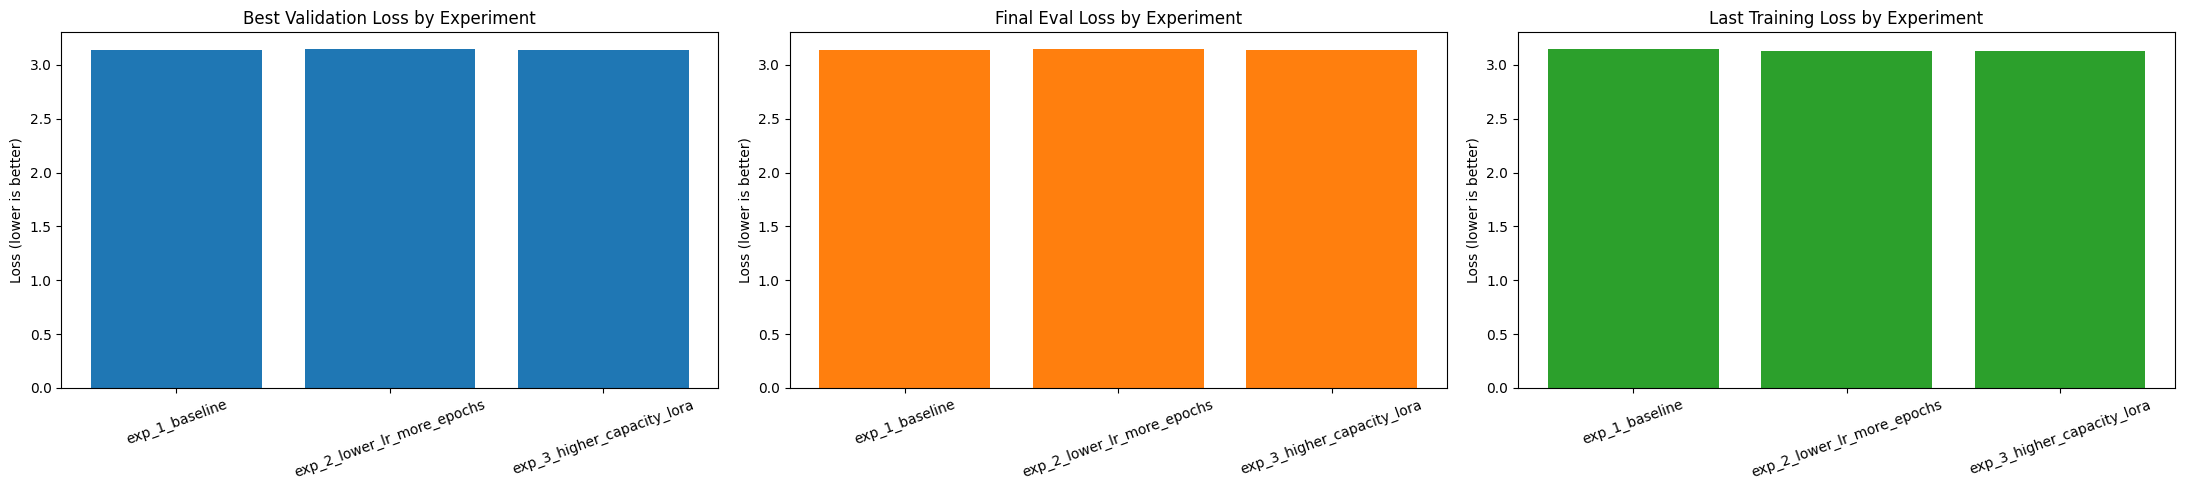

,rank,experiment,best_eval_loss,eval_loss,last_train_loss,adapter_dir
0,1,exp_3_higher_capacity_lora,3.136464,3.136464,3.1330,/content/drive/MyDrive/brainink_janus_hw/janus...
1,2,exp_1_baseline,3.142398,3.142398,3.1450,/content/drive/MyDrive/brainink_janus_hw/janus...
2,3,exp_2_lower_lr_more_epochs,3.145656,3.145656,3.1328,/content/drive/MyDrive/brainink_janus_hw/janus...


In [ ]:
# -------- Comparison plots (to choose the best model) --------
import matplotlib.pyplot as plt

if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    print('No experiment results found. Run the previous cell first.')
else:
    plot_df = results_df.copy()

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    # 1) Best eval loss
    if 'best_eval_loss' in plot_df.columns and plot_df['best_eval_loss'].notna().any():
        axes[0].bar(plot_df['experiment'], plot_df['best_eval_loss'])
        axes[0].set_title('Best Validation Loss by Experiment')
        axes[0].set_ylabel('Loss (lower is better)')
        axes[0].tick_params(axis='x', rotation=20)
    else:
        axes[0].text(0.5, 0.5, 'No best_eval_loss available', ha='center', va='center')
        axes[0].set_title('Best Validation Loss by Experiment')

    # 2) Final eval loss
    if 'eval_loss' in plot_df.columns and plot_df['eval_loss'].notna().any():
        axes[1].bar(plot_df['experiment'], plot_df['eval_loss'], color='tab:orange')
        axes[1].set_title('Final Eval Loss by Experiment')
        axes[1].set_ylabel('Loss (lower is better)')
        axes[1].tick_params(axis='x', rotation=20)
    else:
        axes[1].text(0.5, 0.5, 'No eval_loss available', ha='center', va='center')
        axes[1].set_title('Final Eval Loss by Experiment')

    # 3) Last train loss
    if 'last_train_loss' in plot_df.columns and plot_df['last_train_loss'].notna().any():
        axes[2].bar(plot_df['experiment'], plot_df['last_train_loss'], color='tab:green')
        axes[2].set_title('Last Training Loss by Experiment')
        axes[2].set_ylabel('Loss (lower is better)')
        axes[2].tick_params(axis='x', rotation=20)
    else:
        axes[2].text(0.5, 0.5, 'No last_train_loss available', ha='center', va='center')
        axes[2].set_title('Last Training Loss by Experiment')

    plt.tight_layout()
    plt.show()

    # Ranked summary table
    rank_col = 'best_eval_loss' if 'best_eval_loss' in plot_df.columns and plot_df['best_eval_loss'].notna().any() else 'eval_loss'
    if rank_col in plot_df.columns:
        ranked = plot_df.sort_values(rank_col, ascending=True).reset_index(drop=True)
        ranked.insert(0, 'rank', np.arange(1, len(ranked) + 1))
        display(ranked[['rank', 'experiment', rank_col, 'eval_loss', 'last_train_loss', 'adapter_dir']])
    else:
        display(plot_df)

In [ ]:
# -------- Verify Saved Models on Drive --------
import os

# The training function already saves directly to this path on Drive
print(f"Checking for saved models in: {cfg.work_dir}")

if os.path.exists(cfg.work_dir):
    print("\nFound directories:")
    for item in os.listdir(cfg.work_dir):
        print(f" - {item}")

    adapter_path = os.path.join(cfg.work_dir, 'janus_hw_lora_adapter')
    if os.path.exists(adapter_path):
        print(f"\nSaved Adapters in {adapter_path}:")
        for exp_folder in os.listdir(adapter_path):
            print(f" - {exp_folder}")
else:
    print(f"Directory {cfg.work_dir} does not exist yet. Run the training cells above first.")

Checking for saved models in: /content/drive/MyDrive/brainink_janus_hw

Found directories:
 - crops
 - checkpoints
 - janus_hw_lora_adapter
 - experiment_summaries

Saved Adapters in /content/drive/MyDrive/brainink_janus_hw/janus_hw_lora_adapter:
 - README.md
 - adapter_model.safetensors
 - adapter_config.json
 - tokenizer_config.json
 - special_tokens_map.json
 - tokenizer.json
 - training_meta.json
 - exp_1_baseline
 - exp_2_lower_lr_more_epochs
 - exp_3_higher_capacity_lora


In [ ]:
# -------- Save experiment comparison table --------
if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    print('No results to save. Run training first.')
else:
    summary_dir = Path(cfg.work_dir) / 'experiment_summaries'
    summary_dir.mkdir(parents=True, exist_ok=True)

    csv_out = summary_dir / 'three_run_results.csv'
    json_out = summary_dir / 'three_run_results.json'

    results_df.to_csv(csv_out, index=False)
    with open(json_out, 'w', encoding='utf-8') as f:
        json.dump(results_df.to_dict(orient='records'), f, indent=2)

    print('Saved:', csv_out)
    print('Saved:', json_out)

Saved: /content/drive/MyDrive/brainink_janus_hw/experiment_summaries/three_run_results.csv
Saved: /content/drive/MyDrive/brainink_janus_hw/experiment_summaries/three_run_results.json


Shared eval subset size: 20

Evaluating: exp_1_baseline
Adapter dir: /content/drive/MyDrive/brainink_janus_hw/janus_hw_lora_adapter/exp_1_baseline


Some kwargs in processor config are unused and will not have any effect: add_special_token, mask_prompt, image_tag, ignore_id, num_image_tokens, sft_format. 
Some kwargs in processor config are unused and will not have any effect: add_special_token, mask_prompt, image_tag, ignore_id, num_image_tokens, sft_format. 



Evaluating: exp_2_lower_lr_more_epochs
Adapter dir: /content/drive/MyDrive/brainink_janus_hw/janus_hw_lora_adapter/exp_2_lower_lr_more_epochs


Some kwargs in processor config are unused and will not have any effect: add_special_token, mask_prompt, image_tag, ignore_id, num_image_tokens, sft_format. 
Some kwargs in processor config are unused and will not have any effect: add_special_token, mask_prompt, image_tag, ignore_id, num_image_tokens, sft_format. 



Evaluating: exp_3_higher_capacity_lora
Adapter dir: /content/drive/MyDrive/brainink_janus_hw/janus_hw_lora_adapter/exp_3_higher_capacity_lora


Some kwargs in processor config are unused and will not have any effect: add_special_token, mask_prompt, image_tag, ignore_id, num_image_tokens, sft_format. 
Some kwargs in processor config are unused and will not have any effect: add_special_token, mask_prompt, image_tag, ignore_id, num_image_tokens, sft_format. 



CER/WER ranking (lower is better):


,rank_text_metric,experiment,wer,cer,failed_samples,evaluated_samples
0,1,exp_1_baseline,0.657331,0.544773,0,20
1,2,exp_3_higher_capacity_lora,0.661175,0.550280,0,20
2,3,exp_2_lower_lr_more_epochs,0.700714,0.579907,0,20


,experiment,adapter_dir,checkpoint_dir,eval_loss,best_eval_loss,last_train_loss,last_learning_rate,hp_num_train_epochs,hp_learning_rate,hp_gradient_accumulation_steps,...,hp_lora_dropout,hp_per_device_train_batch_size,hp_per_device_eval_batch_size,hp_weight_decay,hp_warmup_ratio,rank_text_metric,wer,cer,failed_samples,evaluated_samples
0,exp_1_baseline,/content/drive/MyDrive/brainink_janus_hw/janus...,/content/drive/MyDrive/brainink_janus_hw/check...,3.142398,3.142398,3.1450,1.208459e-06,2,0.0002,8,...,0.05,1,1,0.01,0.03,1,0.657331,0.544773,0,20
1,exp_2_lower_lr_more_epochs,/content/drive/MyDrive/brainink_janus_hw/janus...,/content/drive/MyDrive/brainink_janus_hw/check...,3.145656,3.145656,3.1328,6.160164e-07,3,0.0001,8,...,0.05,1,1,0.01,0.05,3,0.700714,0.579907,0,20
2,exp_3_higher_capacity_lora,/content/drive/MyDrive/brainink_janus_hw/janus...,/content/drive/MyDrive/brainink_janus_hw/check...,3.136464,3.136464,3.1330,1.208459e-06,2,0.0002,8,...,0.10,1,1,0.01,0.03,2,0.661175,0.550280,0,20


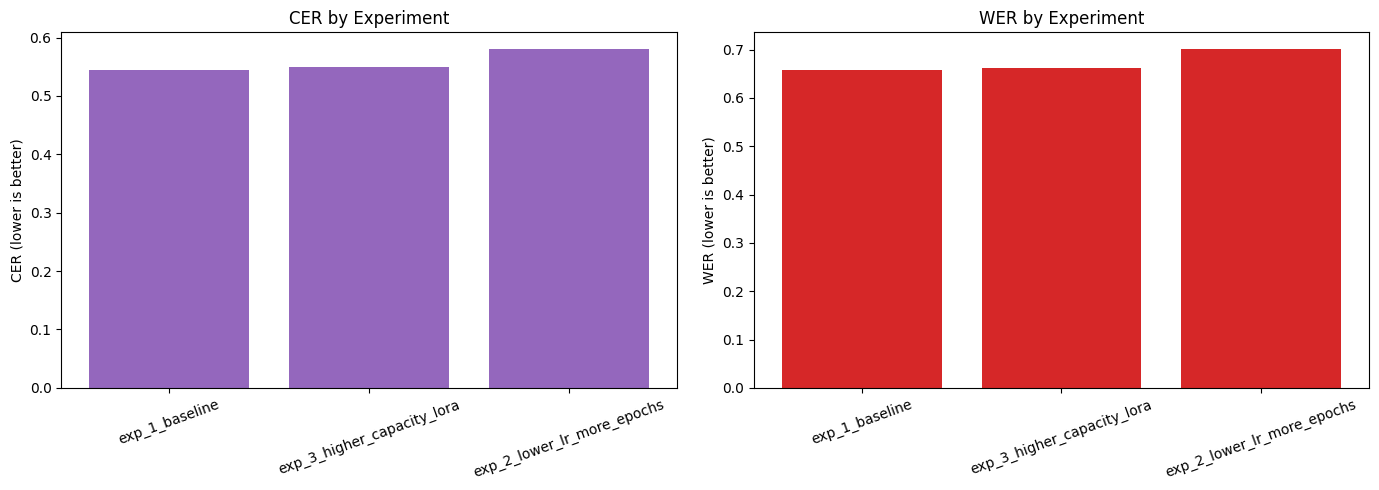

In [ ]:
# CER/WER comparison on the same validation subset (all 3 runs) --------
from jiwer import wer, cer
from peft import PeftModel
from janus.models import VLChatProcessor

# Adjust for faster/slower comparison
EVAL_SUBSET_SIZE = 20  # uses the same subset for every experiment
MAX_NEW_TOKENS = 200


def _build_eval_subset(val_df, subset_size=20, seed=42):
    subset_n = min(subset_size, len(val_df))
    return val_df.sample(subset_n, random_state=seed).reset_index(drop=True)


def _load_model_with_adapter(model_name: str, adapter_dir: str):
    # FIX: Use float16 for compute to avoid BFloat16 vs Half conflicts
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.float16,  # Changed from bfloat16 to float16
    )

    base_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config if torch.cuda.is_available() else None,
        device_map='auto',
        trust_remote_code=True,
    )

    # Attach LoRA adapter to language_model
    base_model.language_model = PeftModel.from_pretrained(base_model.language_model, adapter_dir)
    base_model.eval()

    # Processor/tokenizer from adapter folder if available
    try:
        processor_local = AutoProcessor.from_pretrained(adapter_dir, trust_remote_code=True)
    except Exception:
        processor_local = VLChatProcessor.from_pretrained(model_name)

    vl_processor_local = VLChatProcessor.from_pretrained(model_name)
    return base_model, processor_local, vl_processor_local


def _align_vision_to_lm_dtype(inner_model, prepare_inputs):
    lm_dtype = inner_model.language_model.get_input_embeddings().weight.dtype

    if hasattr(prepare_inputs, 'pixel_values') and prepare_inputs.pixel_values is not None:
        prepare_inputs.pixel_values = prepare_inputs.pixel_values.to(device=inner_model.device, dtype=lm_dtype)

    for module_name in ['vision_model', 'aligner', 'projector']:
        module = getattr(inner_model, module_name, None)
        if module is not None:
            try:
                module.to(dtype=lm_dtype, device=inner_model.device)
            except Exception:
                pass

    return prepare_inputs


def _greedy_decode_without_generate(inner_model, vl_processor_local, inputs_embeds, max_new_tokens=200):
    lm = inner_model.language_model
    tokenizer = vl_processor_local.tokenizer
    eos_id = tokenizer.eos_token_id

    lm_dtype = next(lm.parameters()).dtype
    current_embeds = inputs_embeds.to(device=inner_model.device, dtype=lm_dtype)
    token_embed = lm.get_input_embeddings()
    generated_ids = []

    with torch.no_grad():
        for _ in range(max_new_tokens):
            attn_mask = torch.ones((current_embeds.shape[0], current_embeds.shape[1]), dtype=torch.long, device=current_embeds.device)
            out = lm(
                inputs_embeds=current_embeds,
                attention_mask=attn_mask,
                use_cache=False,
                return_dict=True,
            )

            next_token = torch.argmax(out.logits[:, -1, :], dim=-1)
            token_id = int(next_token.item())
            generated_ids.append(token_id)

            if eos_id is not None and token_id == eos_id:
                break

            next_embed = token_embed(next_token).unsqueeze(1).to(current_embeds.dtype)
            current_embeds = torch.cat([current_embeds, next_embed], dim=1)

    return generated_ids


def _predict_one(inner_model, vl_processor_local, image_path: str):
    img = Image.open(image_path).convert('RGB')

    conversation = [
        {
            'role': 'User',
            'content': '<image_placeholder>\n' + PROMPT,
            'images': [image_path],
        },
        {'role': 'Assistant', 'content': ''},
    ]

    prepare_inputs = vl_processor_local(
        conversations=conversation,
        images=[img],
        force_batchify=True,
    ).to(inner_model.device)

    # First pass
    try:
        with torch.no_grad():
            inputs_embeds = inner_model.prepare_inputs_embeds(**prepare_inputs)
        token_ids = _greedy_decode_without_generate(inner_model, vl_processor_local, inputs_embeds, max_new_tokens=MAX_NEW_TOKENS)
    except RuntimeError as err:
        # Retry with dtype alignment if mismatch occurs
        prepare_inputs = _align_vision_to_lm_dtype(inner_model, prepare_inputs)
        with torch.no_grad():
            inputs_embeds = inner_model.prepare_inputs_embeds(**prepare_inputs)
        token_ids = _greedy_decode_without_generate(inner_model, vl_processor_local, inputs_embeds, max_new_tokens=MAX_NEW_TOKENS)

    pred = vl_processor_local.tokenizer.decode(token_ids, skip_special_tokens=True)
    return pred.strip()


if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    print('No experiment results found. Run the 3-experiment training cell first.')
elif 'val_df' not in globals() or val_df is None or len(val_df) == 0:
    print('Validation dataframe not found. Run dataset prep cells first.')
else:
    shared_eval_df = _build_eval_subset(val_df, subset_size=EVAL_SUBSET_SIZE, seed=SEED)
    print('Shared eval subset size:', len(shared_eval_df))

    text_metrics_rows = []

    for _, run_row in results_df.iterrows():
        exp_name = run_row['experiment']
        adapter_dir = run_row['adapter_dir']

        print('\n' + '=' * 90)
        print('Evaluating:', exp_name)
        print('Adapter dir:', adapter_dir)

        refs, preds = [], []
        failed = 0

        try:
            inner_model, _, vl_processor_local = _load_model_with_adapter(cfg.model_name, adapter_dir)

            for _, ex in shared_eval_df.iterrows():
                ref_text = str(ex['target_text'])
                img_path = str(ex['input_path'])

                try:
                    pred_text = _predict_one(inner_model, vl_processor_local, img_path)
                except Exception as sample_err:
                    failed += 1
                    pred_text = ''
                    print('Sample failed:', sample_err)

                refs.append(ref_text)
                preds.append(pred_text)

            run_wer = wer(refs, preds)
            run_cer = cer(refs, preds)

            text_metrics_rows.append({
                'experiment': exp_name,
                'wer': float(run_wer),
                'cer': float(run_cer),
                'failed_samples': int(failed),
                'evaluated_samples': int(len(shared_eval_df)),
            })

        finally:
            del inner_model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    text_metrics_df = pd.DataFrame(text_metrics_rows)

    if not text_metrics_df.empty:
        text_metrics_df = text_metrics_df.sort_values(['cer', 'wer'], ascending=[True, True]).reset_index(drop=True)
        text_metrics_df.insert(0, 'rank_text_metric', np.arange(1, len(text_metrics_df) + 1))
        print('\nCER/WER ranking (lower is better):')
        display(text_metrics_df)

        # Merge with existing loss-based results for final comparison
        merged_compare_df = results_df.merge(text_metrics_df, on='experiment', how='left')
        display(merged_compare_df)

        # Plot CER/WER bars
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].bar(text_metrics_df['experiment'], text_metrics_df['cer'], color='tab:purple')
        axes[0].set_title('CER by Experiment')
        axes[0].set_ylabel('CER (lower is better)')
        axes[0].tick_params(axis='x', rotation=20)

        axes[1].bar(text_metrics_df['experiment'], text_metrics_df['wer'], color='tab:red')
        axes[1].set_title('WER by Experiment')
        axes[1].set_ylabel('WER (lower is better)')
        axes[1].tick_params(axis='x', rotation=20)

        plt.tight_layout()
        plt.show()
    else:
        print('No CER/WER results produced.')